In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
dataset = pd.read_csv('mental-heath-in-tech-2016_20161114.csv')

In [3]:
dataset.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [4]:
print(dataset.iloc[13])

Are you self-employed?                                                                                                               0
How many employees does your company or organization have?                                                                     100-500
Is your employer primarily a tech company/organization?                                                                            0.0
Is your primary role within your company related to tech/IT?                                                                       1.0
Does your employer provide mental health benefits as part of healthcare coverage?                                                  Yes
                                                                                                           ...                        
What US state or territory do you live in?                                                                                         NaN
What country do you work in?                           

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   object 
 2   Is your employer primarily a tech company/organization?     

**PREPROCESSING, DATA FILTERING, AND DATA CLEANING**

In [6]:
dataset['How many employees does your company or organization have?'].fillna(dataset['How many employees does your company or organization have?'].mode()[0], inplace= True)

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1313871895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['How many employees does your company or organization have?'].fillna(dataset['How many employees does your company or organization have?'].mode()[0], inplace= True)


In [7]:
print((dataset['How many employees does your company or organization have?'].unique()))
print((dataset['How many employees does your company or organization have?'].isnull()).sum())

['26-100' '6-25' 'More than 1000' '100-500' '500-1000' '1-5']
0


In [8]:
dataset['How many employees does your company or organization have?'] = dataset['How many employees does your company or organization have?'].replace({'1-5': 6, '6-25': 5, '26-100': 4, '100-500': 3, '500-1000': 2, 'More than 1000': 1 }).astype(int)

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4225916503.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['How many employees does your company or organization have?'] = dataset['How many employees does your company or organization have?'].replace({'1-5': 6, '6-25': 5, '26-100': 4, '100-500': 3, '500-1000': 2, 'More than 1000': 1 }).astype(int)


In [9]:
print((dataset['How many employees does your company or organization have?'].unique()))
print((dataset['How many employees does your company or organization have?'] == 4).sum())
print((dataset['How many employees does your company or organization have?'] == 1).sum())
print((dataset['How many employees does your company or organization have?'] == 3).sum())
print((dataset['How many employees does your company or organization have?'] == 5).sum())
print((dataset['How many employees does your company or organization have?'] == 2).sum())
print((dataset['How many employees does your company or organization have?'] == 6).sum())

[4 5 1 3 2 6]
579
256
248
210
80
60


In [10]:
dataset.drop(['What US state or territory do you work in?', 'What country do you work in?', 'What US state or territory do you live in?', 'What country do you live in?', 'If maybe, what condition(s) do you believe you have?', 'If yes, what condition(s) have you been diagnosed with?', 
              'Do you have previous employers?', 'Would you be willing to bring up a physical health issue with a potential employer in an interview?', 'Why or why not?', 'Why or why not?', 'If yes, what condition(s) have you been diagnosed with?', 'If maybe, what condition(s) do you believe you have?', 'If so, what condition(s) were you diagnosed with?' ], axis= 1, inplace= True)

In [11]:
dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].fillna(dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].mode()[0], inplace= True)
dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'] = dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}).astype(int)
dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3237592451.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].fillna(dataset['Does your employer offer resources to learn more about mental health concerns and options for seeking help?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3237592451.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remove

array([0, 2, 1])

In [12]:
dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].fillna(dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].mode()[0], inplace= True)
dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'] = dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}).astype(int)
dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1820416467.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].fillna(dataset['Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1820416467.py:2: FutureWarning: Downcasting 

array([0, 2, 1])

In [13]:
dataset['Do you know the options for mental health care available under your employer-provided coverage?'].fillna(dataset['Do you know the options for mental health care available under your employer-provided coverage?'].mode()[0], inplace= True)
dataset['Do you know the options for mental health care available under your employer-provided coverage?'] = dataset['Do you know the options for mental health care available under your employer-provided coverage?'].replace({'No': 0, "I am not sure": 1, 'Yes': 2}).astype(int)
dataset['Do you know the options for mental health care available under your employer-provided coverage?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3458432347.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you know the options for mental health care available under your employer-provided coverage?'].fillna(dataset['Do you know the options for mental health care available under your employer-provided coverage?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3458432347.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. T

array([0, 2, 1])

In [14]:
dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].fillna(dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].mode()[0], inplace= True)
dataset['Does your employer provide mental health benefits as part of healthcare coverage?'] = dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].replace({'Not eligible for coverage / N/A': 0, 'No': 0, "I don't know": 1, 'Yes': 2}).astype(int)
dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4109831038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].fillna(dataset['Does your employer provide mental health benefits as part of healthcare coverage?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4109831038.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, e

array([0, 2, 1])

In [15]:
dataset['Benefits Or Help Provided for Mental Health'] = dataset[['Does your employer provide mental health benefits as part of healthcare coverage?', 'Do you know the options for mental health care available under your employer-provided coverage?', 'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?', 'Does your employer offer resources to learn more about mental health concerns and options for seeking help?' ]].sum(axis= 1)

In [16]:
dataset.drop(['Does your employer provide mental health benefits as part of healthcare coverage?', 'Do you know the options for mental health care available under your employer-provided coverage?', 'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?', 'Does your employer offer resources to learn more about mental health concerns and options for seeking help?', 'Why or why not?.1'], axis= 1, inplace= True)

In [17]:
dataset.drop(['Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?', 'Do you know local or online resources to seek help for a mental health disorder?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?',
            'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?', 'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?',
            'Do you believe your productivity is ever affected by a mental health issue?', 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?'], axis= 1, inplace= True)

In [18]:
dataset.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health
0,0,4,1.0,NaN,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,Yes,0,Not applicable to

In [19]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 41 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1433 non-null   int64  
 2   Is your employer primarily a tech company/organization?     

In [20]:
print(dataset.iloc[13])

Are you self-employed?                                                                                                                                                                                                              0
How many employees does your company or organization have?                                                                                                                                                                          3
Is your employer primarily a tech company/organization?                                                                                                                                                                           0.0
Is your primary role within your company related to tech/IT?                                                                                                                                                                      1.0
Is your anonymity protected if you choose to take advantage of mental health or 

In [21]:
dataset['Have your previous employers provided mental health benefits?'].fillna(dataset['Have your previous employers provided mental health benefits?'].mode()[0], inplace= True)
dataset['Have your previous employers provided mental health benefits?'] = dataset['Have your previous employers provided mental health benefits?'].replace({'No, none did': 0, "I don't know": 1, 'Some did': 1, 'Yes, they all did': 2}).astype(int)
dataset['Have your previous employers provided mental health benefits?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\11554215.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Have your previous employers provided mental health benefits?'].fillna(dataset['Have your previous employers provided mental health benefits?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\11554215.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

array([0, 2, 1])

In [22]:
dataset['Were you aware of the options for mental health care provided by your previous employers?'].fillna(dataset['Were you aware of the options for mental health care provided by your previous employers?'].mode()[0], inplace= True)
dataset['Were you aware of the options for mental health care provided by your previous employers?'] = dataset['Were you aware of the options for mental health care provided by your previous employers?'].replace({'No, I only became aware later': 0, 'I was aware of some': 1, "N/A (not currently aware)": 1, 'Yes, I was aware of all of them': 2}).astype(int)
dataset['Were you aware of the options for mental health care provided by your previous employers?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3244417788.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Were you aware of the options for mental health care provided by your previous employers?'].fillna(dataset['Were you aware of the options for mental health care provided by your previous employers?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3244417788.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the

array([1, 2, 0])

In [23]:
dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].fillna(dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].mode()[0], inplace= True)
dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'] = dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].replace({'None did': 0, 'Some did': 1, 'Yes, they all did': 2}).astype(int)
dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1877278479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].fillna(dataset['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1877278479.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remo

array([0, 1, 2])

In [24]:
dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].fillna(dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].mode()[0], inplace= True)
dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'] = dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].replace({'None did': 0, "I don't know": 1, 'Some did': 1, 'Yes, they all did': 2}).astype(int)
dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2988196800.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].fillna(dataset['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2988196800.py:2: FutureWarning: Downcasting behavior i

array([1, 0, 2])

In [25]:
dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].fillna(dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].mode()[0], inplace= True)
dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'] = dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].replace({'None of them': 0, 'Some of them': 1, "I don't know": 1, 'Yes, all of them': 2}).astype(int)
dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1464628544.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].fillna(dataset['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1464628544.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will b

array([1, 0, 2])

In [26]:
dataset['Previously provided benefits for Mental Health'] = dataset[['Have your previous employers provided mental health benefits?', 'Were you aware of the options for mental health care provided by your previous employers?', 'Did your previous employers provide resources to learn more about mental health issues and how to seek help?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?']].sum(axis= 1)

In [27]:
dataset.drop(['Have your previous employers provided mental health benefits?', 'Were you aware of the options for mental health care provided by your previous employers?', 'Did your previous employers provide resources to learn more about mental health issues and how to seek help?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'], axis= 1, inplace= True)

In [28]:
dataset['Do you work remotely?'].replace({'Never': 0, 'Sometimes': 1, 'Always': 2}, inplace= True)
dataset['Do you work remotely?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\351543708.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you work remotely?'].replace({'Never': 0, 'Sometimes': 1, 'Always': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\351543708.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_

array([1, 0, 2])

In [29]:
dataset['What is your gender?'].fillna(dataset['What is your gender?'].mode()[0], inplace= True)
gender_mapping = {'Male': 1, 'male': 1, 'Male ': 1, 'm': 1, 'M': 1, 'Male.': 1, 'Man': 1, 'Sex is male': 1, 'MALE': 1, 'male (cis)': 1, "I'm a man why didn't you make this a drop down question. You should of asked sex? And I would of answered yes please. Seriously how much text can this take? ": 1, 'male ': 1, 'Female': 2, ' Female': 2, 'female': 2, 'I identify as female.': 2, 'I identify as female': 2, 'female ': 2, 'F': 2, 'Woman': 2, 'f': 2, 'fm': 2, 'woman': 2, 'female/woman': 2, 'Female ': 2}
dataset['What is your gender?'] = dataset['What is your gender?'].map(gender_mapping).fillna(3).astype(int)
dataset['What is your gender?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2831725582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['What is your gender?'].fillna(dataset['What is your gender?'].mode()[0], inplace= True)


array([1, 2, 3])

In [30]:
dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].fillna(dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].mode()[0], inplace= True)
dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\96569457.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].fillna(dataset['Do you think that discussing a mental health disorder with your employer would have negative consequences?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\96569457.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a

array([0, 1, 2])

In [31]:
dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].fillna(dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].mode()[0], inplace= True)
dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\883956526.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].fillna(dataset['Would you feel comfortable discussing a mental health disorder with your coworkers?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\883956526.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior,

array([1, 2, 0])

In [32]:
dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].fillna(dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].mode()[0], inplace= True)
dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\549187265.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].fillna(dataset['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\549187265.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To re

array([2, 1, 0])

In [33]:
dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].fillna(dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].mode()[0], inplace= True)
dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].replace({'No': 0, 'Yes': 1}, inplace= True)
dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].unique()


C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4257314099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].fillna(dataset['Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'].mode()[0], inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4257314099.py:2: FutureWarning: Downcasting behavi

array([0, 1])

In [34]:
dataset['Comfort of discussing mental health'] = dataset[['Would you feel comfortable discussing a mental health disorder with your coworkers?', 'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?']].sum(axis= 1)

In [35]:
dataset['Consequences of discussing mental health'] = dataset[['Do you think that discussing a mental health disorder with your employer would have negative consequences?', 'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?']].sum(axis= 1)

In [36]:
dataset.drop(['Would you feel comfortable discussing a mental health disorder with your coworkers?', 'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?', 'Do you think that discussing a mental health disorder with your employer would have negative consequences?', 'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?'], axis= 1, inplace= True)

In [37]:
dataset.drop(['Do you think that discussing a physical health issue with your employer would have negative consequences?', 'Do you feel that your employer takes mental health as seriously as physical health?'], inplace= True, axis= 1)

In [38]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 34 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1433 non-null   int64  
 2   Is your employer primarily a tech company/organization?     

In [39]:
dataset.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health
0,0,4,1.0,NaN,I don't know,Very easy,I don't know,1,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Maybe,"No, I don't think they would",Somewhat open,No,NaN,No,Yes,No,Yes,0,Not applicable to me,Not applicable to me,39,1,Back-end Developer,1,0,2,3,0
1,0,5,1.0,NaN,Yes,Somewhat easy,"Yes, always",0,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,No,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,Yes,Yes,Yes,Yes,1,Rarely,Sometimes,29,1,Back-end Developer|Front-end Developer,0,6,4,3,0
2,0,5,1.0,NaN,I don't know,Neither easy nor difficult,I don't know,1,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,No,1,Not applicable to me,Not applicable to me,38,1,Back-end Developer,2,0,2,2,1
3,1,4,NaN,NaN,NaN,NaN,I don't know,1,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Maybe,"Yes, I think it would",Maybe,Neutral,No,NaN,No,Yes,Yes,Yes,1,Sometimes,Sometimes,43,1,Supervisor/Team Lead,1,2,2,3,1
4,0,5,0.0,1.0,No,Neither easy nor difficult,

REASON FOR GIVING 1 VALUE TO THIS COLUMN IS THAT ALL THE ROLES SHOULD HAVE EQUAL REPRESENTATION

In [40]:
dataset['Which of the following best describes your work position?'] = dataset['Which of the following best describes your work position?'] = 1
dataset['Which of the following best describes your work position?'].unique()

array([1])

In [41]:
dataset['Do you currently have a mental health disorder?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Do you currently have a mental health disorder?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2450922621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you currently have a mental health disorder?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2450922621.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option(

array([0, 2, 1])

In [42]:
dataset['Have you been diagnosed with a mental health condition by a medical professional?'].replace({'No': 0, 'Yes': 1}, inplace= True)
dataset['Have you been diagnosed with a mental health condition by a medical professional?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2259694753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Have you been diagnosed with a mental health condition by a medical professional?'].replace({'No': 0, 'Yes': 1}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2259694753.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavio

array([1, 0])

In [43]:
dataset['Have you had a mental health disorder in the past?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Have you had a mental health disorder in the past?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3406422620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Have you had a mental health disorder in the past?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3406422620.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_opti

array([2, 1, 0])

In [44]:
dataset['Do you have a family history of mental illness?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}, inplace= True)
dataset['Do you have a family history of mental illness?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2181018958.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you have a family history of mental illness?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2181018958.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_

array([0, 2, 1])

In [45]:
dataset['History of mental issues'] = dataset[['Have you had a mental health disorder in the past?', 'Do you have a family history of mental illness?']].sum(axis= 1)

In [46]:
dataset.drop(['Have you had a mental health disorder in the past?', 'Do you have a family history of mental illness?'], axis= 1, inplace= True)

In [47]:
dataset.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues
0,0,4,1.0,NaN,I don't know,Very easy,I don't know,1,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Maybe,"No, I don't think they would",Somewhat open,No,NaN,0,1,0,Not applicable to me,Not applicable to me,39,1,1,1,0,2,3,0,2
1,0,5,1.0,NaN,Yes,Somewhat easy,"Yes, always",0,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,No,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,2,1,1,Rarely,Sometimes,29,1,1,0,6,4,3,0,4
2,0,5,1.0,NaN,I don't know,Neither easy nor difficult,I don't know,1,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,0,0,1,Not applicable to me,Not applicable to me,38,1,1,2,0,2,2,1,1
3,1,4,NaN,NaN,NaN,NaN,I don't know,1,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Maybe,"Yes, I think it would",Maybe,Neutral,No,NaN,2,1,1,Sometimes,Sometimes,43,1,1,1,2,2,3,1,2
4,0,5,0.0,1.0,No,Neither easy nor difficult,I don't know,1,Some of them,"No, at none of my previous employers",Some of my previous employers,Some did,Some of them,No,"Yes, I think it would",Maybe,Somewhat open,"Yes, I experienced",Yes,2,1,1,Som

In [48]:
dataset['Would you bring up a mental health issue with a potential employer in an interview?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
dataset['Would you bring up a mental health issue with a potential employer in an interview?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\518576399.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Would you bring up a mental health issue with a potential employer in an interview?'].replace({'No': 0, 'Maybe': 1, 'Yes': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\518576399.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the fu

array([1, 0, 2])

In [49]:
dataset.drop(['Do you think that discussing a physical health issue with previous employers would have negative consequences?'], inplace= True, axis= 1)

In [50]:
dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'] = dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].fillna(dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].mode()[0])
dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].isnull().sum()
dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].replace({'No, at none of my previous employers': 0, 'Some of my previous employers': 1, 'Yes, at all of my previous employers': 2}, inplace= True)
dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\628066663.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Would you have been willing to discuss a mental health issue with your previous co-workers?'].replace({'No, at none of my previous employers': 0, 'Some of my previous employers': 1, 'Yes, at all of my previous employers': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\628066663.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. 

array([1, 0, 2])

In [51]:
dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].isnull().sum()
dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'] = dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].fillna(dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].mode()[0])
dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].replace({'No, at none of my previous employers': 0, 'Some of my previous employers': 1, "I don't know": 1, 'Yes, at all of my previous employers': 2}, inplace= True)
dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].unique()


C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4074064370.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].replace({'No, at none of my previous employers': 0, 'Some of my previous employers': 1, "I don't know": 1, 'Yes, at all of my previous employers': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\4074064370.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

array([1, 0, 2])

In [52]:
dataset['Willingness to discuss mental health with previous employers'] = dataset[['Would you have been willing to discuss a mental health issue with your previous co-workers?', 'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?']].sum(axis= 1)

In [ ]:
dataset.drop(['Would you have been willing to discuss a mental health issue with your previous co-workers?', 'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'], inplace= True, axis= 1)

In [54]:
dataset.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers
0,0,4,1.0,NaN,I don't know,Very easy,I don't know,1,I don't know,None of them,1,Maybe,"No, I don't think they would",Somewhat open,No,NaN,0,1,0,Not applicable to me,Not applicable to me,39,1,1,1,0,2,3,0,2,2
1,0,5,1.0,NaN,Yes,Somewhat easy,"Yes, always",0,Some did,None of them,0,"No, I don't think it would","No, I don't think they would",Somewhat open,No,NaN,2,1,1,Rarely,Sometimes,29,1,1,0,6,4,3,0,4,1
2,0,5,1.0,NaN,I don't know,Neither easy nor difficult,I don't know,1,I don't know,Some of them,2,Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,0,0,1,Not applicable to me,Not applicable to me,38,1,1,2,0,2,2,1,1,2
3,1,4,NaN,NaN,NaN,NaN,I don't know,1,I don't know,Some of them,1,"Yes, I think it would",Maybe,Neutral,No,NaN,2,1,1,Sometimes,Sometimes,43,1,1,1,2,2,3,1,2,2
4,0,5,0.0,1.0,No,Neither easy nor difficult,I don't know,1,Some did,Some of them,0,"Yes, I think it would",Maybe,Somewhat open,"Yes, I experienced",Yes,2,1,1,Sometimes,Sometimes,43,2,1,1,4,3,1,2,4,1


In [55]:
dataset['Is your employer primarily a tech company/organization?'] = dataset['Is your employer primarily a tech company/organization?'].fillna(dataset['Is your employer primarily a tech company/organization?'].mode()[0])
dataset['Is your employer primarily a tech company/organization?'] = dataset['Is your employer primarily a tech company/organization?'].astype(int)
dataset['Is your employer primarily a tech company/organization?'].unique()
print((dataset['Is your employer primarily a tech company/organization?'] == 0).sum())

263


DROPPING THE ROWS THAT SPECIFICALLY MENTION THEY ARE NOT RELATED TO TECH

In [56]:
dataset['Is your primary role within your company related to tech/IT?'] = dataset['Is your primary role within your company related to tech/IT?'].fillna(1)
dataset['Is your primary role within your company related to tech/IT?'] = dataset['Is your primary role within your company related to tech/IT?'].astype(int)
dataset= dataset[dataset['Is your primary role within your company related to tech/IT?'] != 0]
print((dataset['Is your primary role within your company related to tech/IT?'] == 0).sum())
dataset['Is your primary role within your company related to tech/IT?'].unique()

0


array([1])

In [57]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1418 entries, 0 to 1432
Data columns (total 31 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype 
---  ------                                                                                                                                                                            --------------  ----- 
 0   Are you self-employed?                                                                                                                                                            1418 non-null   int64 
 1   How many employees does your company or organization have?                                                                                                                        1418 non-null   int64 
 2   Is your employer primarily a tech company/organization?              

In [58]:
dataset.drop(['Are you self-employed?', 'Did you feel that your previous employers took mental health as seriously as physical health?', 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:'], inplace= True, axis= 1)

In [59]:
dataset['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'].replace({'Not applicable to me': 0, 'Never': 0, 'Sometimes': 1, 'Rarely': 1,  'Often': 2}, inplace= True)
dataset['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3560914564.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'].replace({'Not applicable to me': 0, 'Never': 0, 'Sometimes': 1, 'Rarely': 1,  'Often': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3560914564.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the 

array([0, 1, 2])

In [60]:
dataset['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'].replace({'Not applicable to me': 0, 'Never': 0, 'Rarely': 1, 'Sometimes': 1, 'Often': 2}, inplace= True)
dataset['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1059175416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'].replace({'Not applicable to me': 0, 'Never': 0, 'Rarely': 1, 'Sometimes': 1, 'Often': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1059175416.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

array([0, 1, 2])

In [61]:
dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'] = dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].fillna(dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].mode()[0])
dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].replace({'No': 0, 'Maybe/Not sure': 1, 'Yes, I experienced': 2, 'Yes, I observed': 2}, inplace= True)
dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2647205266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].replace({'No': 0, 'Maybe/Not sure': 1, 'Yes, I experienced': 2, 'Yes, I observed': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2647205266.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future versi

array([0, 1, 2])

DROPPING THIS COLUMN BECAUSE OF A LARGE NUMBER OF MISSING VALUES (770)

In [62]:
dataset.drop(['Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?'], inplace= True, axis= 1)

In [63]:
dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'] = dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'].fillna(dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'].mode()[0])
dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}, inplace= True)
dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3329459629.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'].replace({'No': 0, "I don't know": 1, 'Yes': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3329459629.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, exp

array([1, 2, 0])

In [64]:
dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'] = dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].fillna(dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].mode()[0])
dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].replace({'No': 0, "I don't know": 1, 'Sometimes': 1, 'Yes, always': 2}, inplace= True)
dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\851877817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].replace({'No': 0, "I don't know": 1, 'Sometimes': 1, 'Yes, always': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\851877817.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

array([1, 2, 0])

In [65]:
dataset['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?'].replace({ 'No, they do not': 0, "No, I don't think they would": 1, 'Maybe': 1, 'Yes, I think they would': 1, 'Yes, they do': 2}, inplace= True)
dataset['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\753499202.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?'].replace({ 'No, they do not': 0, "No, I don't think they would": 1, 'Maybe': 1, 'Yes, I think they would': 1, 'Yes, they do': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\753499202.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will 

array([1, 2, 0])

In [66]:
dataset['Do you feel that being identified as a person with a mental health issue would hurt your career?'].replace({'No, it has not': 0, "No, I don't think it would": 1, 'Maybe': 1, 'Yes, I think it would': 1, 'Yes, it has': 2}, inplace= True)
dataset['Do you feel that being identified as a person with a mental health issue would hurt your career?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2189241231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Do you feel that being identified as a person with a mental health issue would hurt your career?'].replace({'No, it has not': 0, "No, I don't think it would": 1, 'Maybe': 1, 'Yes, I think it would': 1, 'Yes, it has': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\2189241231.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To 

array([1, 0, 2])

In [67]:
dataset['Fear of others behavior, if mentally ill'] = dataset[['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?', 'Do you feel that being identified as a person with a mental health issue would hurt your career?']].sum(axis= 1)

In [68]:
dataset.drop(['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?', 'Do you feel that being identified as a person with a mental health issue would hurt your career?'], inplace= True, axis= 1)

In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1418 entries, 0 to 1432
Data columns (total 26 columns):
 #   Column                                                                                                                                          Non-Null Count  Dtype 
---  ------                                                                                                                                          --------------  ----- 
 0   How many employees does your company or organization have?                                                                                      1418 non-null   int64 
 1   Is your employer primarily a tech company/organization?                                                                                         1418 non-null   int64 
 2   Is your primary role within your company related to tech/IT?                                                                                    1418 non-null   int64 
 3   Is your anonymity protected if yo

In [70]:
dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'] = dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].fillna(dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].mode()[0])
dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].replace({'None of them': 0, 'Some of them': 1, 'Yes, all of them': 2}, inplace= True)
dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3954803298.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].replace({'None of them': 0, 'Some of them': 1, 'Yes, all of them': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\3954803298.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

array([0, 1, 2])

In [71]:
dataset['Saw negative attitude towards mental health problems (Current or Previous Workplace)'] = dataset[['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?', 'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?']].sum(axis= 1)

In [72]:
dataset.drop(['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?' ,'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'], inplace= True, axis= 1)

In [73]:
dataset['How willing would you be to share with friends and family that you have a mental illness?'].replace({'Not applicable to me (I do not have a mental illness)': 0, 'Not open at all': 0, 'Somewhat not open': 1, 'Somewhat open': 1, 'Neutral': 1, 'Very open': 2}, inplace= True)
dataset['How willing would you be to share with friends and family that you have a mental illness?'].unique()

C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1081156082.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['How willing would you be to share with friends and family that you have a mental illness?'].replace({'Not applicable to me (I do not have a mental illness)': 0, 'Not open at all': 0, 'Somewhat not open': 1, 'Somewhat open': 1, 'Neutral': 1, 'Very open': 2}, inplace= True)
C:\Users\arioc\AppData\Local\Temp\ipykernel_13328\1081156082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and wil

array([1, 0, 2])

In [74]:
dataset.to_csv('Cleaned Mental Health Data.csv', index= False)

In [75]:
group1_features = dataset[['How many employees does your company or organization have?', 
                                            'Do you currently have a mental health disorder?',
                                            'Do you work remotely?', 
                                            'Benefits Or Help Provided for Mental Health']]

In [78]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
kmeans = KMeans()

For K = 2, the average Silhouette Score is: 0.42
For K = 3, the average Silhouette Score is: 0.28
For K = 4, the average Silhouette Score is: 0.26
For K = 5, the average Silhouette Score is: 0.28
For K = 6, the average Silhouette Score is: 0.29
For K = 7, the average Silhouette Score is: 0.28
For K = 8, the average Silhouette Score is: 0.29
For K = 9, the average Silhouette Score is: 0.27
For K = 10, the average Silhouette Score is: 0.28
For K = 11, the average Silhouette Score is: 0.28
For K = 12, the average Silhouette Score is: 0.29
For K = 13, the average Silhouette Score is: 0.29
For K = 14, the average Silhouette Score is: 0.27
For W = 2, the WCSS (inertia) is: 5904.395231
For W = 3, the WCSS (inertia) is: 4865.146957
For W = 4, the WCSS (inertia) is: 4155.208540
For W = 5, the WCSS (inertia) is: 3523.730531
For W = 6, the WCSS (inertia) is: 3128.568168
For W = 7, the WCSS (inertia) is: 2774.814159
For W = 8, the WCSS (inertia) is: 2524.531814
For W = 9, the WCSS (inertia) is: 24

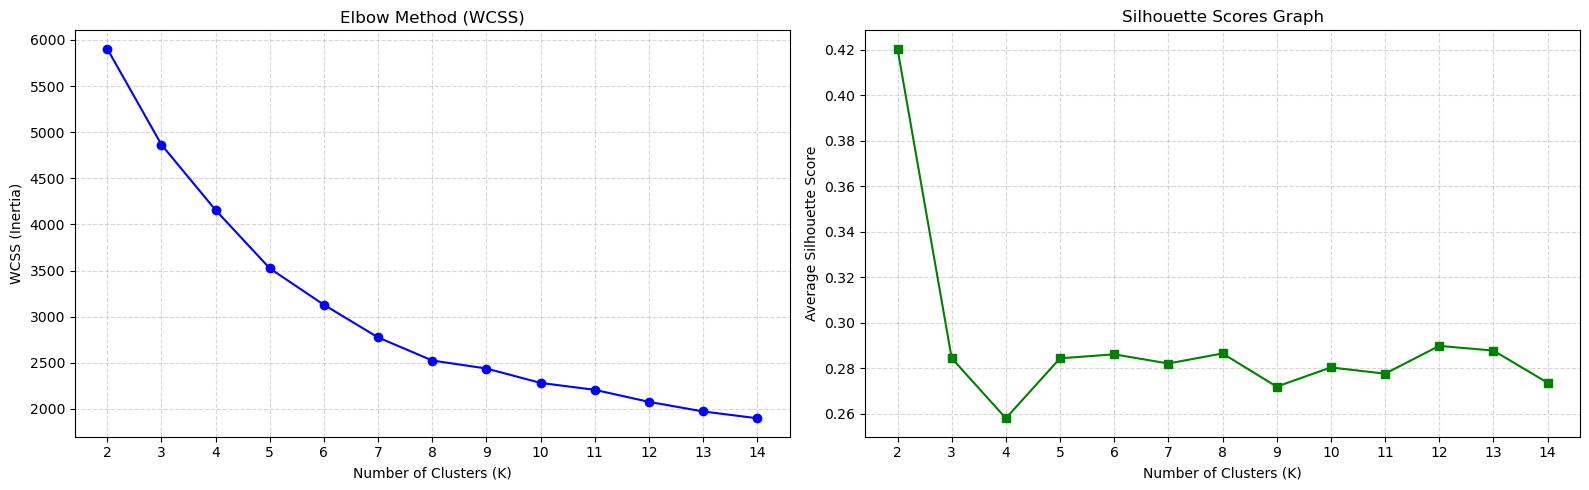

In [77]:
k_range = range(2, 15)
silhouette_scores =[]
for k in k_range:
    kmeans_eval = KMeans(n_clusters= k, random_state= 42, n_init= 10)
    cluster_labels = kmeans_eval.fit_predict(group1_features)

    # Calculate the average silhouette score for this K
    score = silhouette_score(group1_features, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")
    
#WCSS
 
wcss = []
wcss_range = range (2, 15)

for w in wcss_range:

    kmeans_eval = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow= kmeans_eval.fit(group1_features)
    wcss.append(elbow.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow.inertia_:2f}")
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range, wcss, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

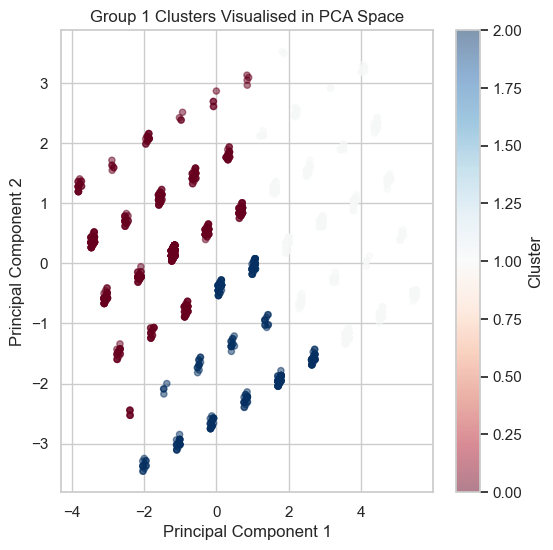

Total information retained from the 4 columns: 84.04%


In [135]:
group1_features = dataset[['How many employees does your company or organization have?', 
                                                        'Do you currently have a mental health disorder?',
                                                        'Do you work remotely?', 
                                                        'Benefits Or Help Provided for Mental Health']]

kmeans= KMeans(n_clusters= 3, random_state= 0)
dataset['Employee Mental Health across different Workplace Environments']= kmeans.fit_predict(group1_features)

# REDUCING THE DIMENSIONS
pca= PCA(n_components= 2)
pca_transformed= pca.fit_transform(group1_features)

# CREATING THE DATAFRAME FOR EASY VISUALISATION
pca_df= pd.DataFrame(pca_transformed, columns=['PC1', 'PC2'])

# ADDING CLUSTER LABELS
pca_df['Group1_clusters']= dataset['Employee Mental Health across different Workplace Environments']

# PLOTTING

plt.figure(figsize=(6, 6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c= dataset['Employee Mental Health across different Workplace Environments'],
    cmap= 'RdBu',
    alpha= 0.5,
    s= 20
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 1 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca.explained_variance_ratio_) * 100
print(f"Total information retained from the 4 columns: {variance_captured:.2f}%")

In [81]:
#                                         --------- GROUP 2 ---------
#       MENTAL HEALTH STIGMA AND ITS IMPACE ON EMPLOYEE PERFORMANCE

group2_features= dataset[['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                            'Consequences of discussing mental health',
                                            'History of mental issues',
                                            'Fear of others behavior, if mentally ill',
                                            'Saw negative attitude towards mental health problems (Current or Previous Workplace)']]

For K = 2, the average Silhouette Score is: 0.36
For K = 3, the average Silhouette Score is: 0.33
For K = 4, the average Silhouette Score is: 0.30
For K = 5, the average Silhouette Score is: 0.31
For K = 6, the average Silhouette Score is: 0.30
For K = 7, the average Silhouette Score is: 0.28
For K = 8, the average Silhouette Score is: 0.25
For K = 9, the average Silhouette Score is: 0.25
For K = 10, the average Silhouette Score is: 0.27
For K = 11, the average Silhouette Score is: 0.28
For K = 12, the average Silhouette Score is: 0.28
For K = 13, the average Silhouette Score is: 0.28
For K = 14, the average Silhouette Score is: 0.29
For W = 2, the WCSS (inertia) is: 4166.045305
For W = 3, the WCSS (inertia) is: 3042.915344
For W = 4, the WCSS (inertia) is: 2535.196890
For W = 5, the WCSS (inertia) is: 2175.018824
For W = 6, the WCSS (inertia) is: 1998.354467
For W = 7, the WCSS (inertia) is: 1837.584832
For W = 8, the WCSS (inertia) is: 1753.812755
For W = 9, the WCSS (inertia) is: 16

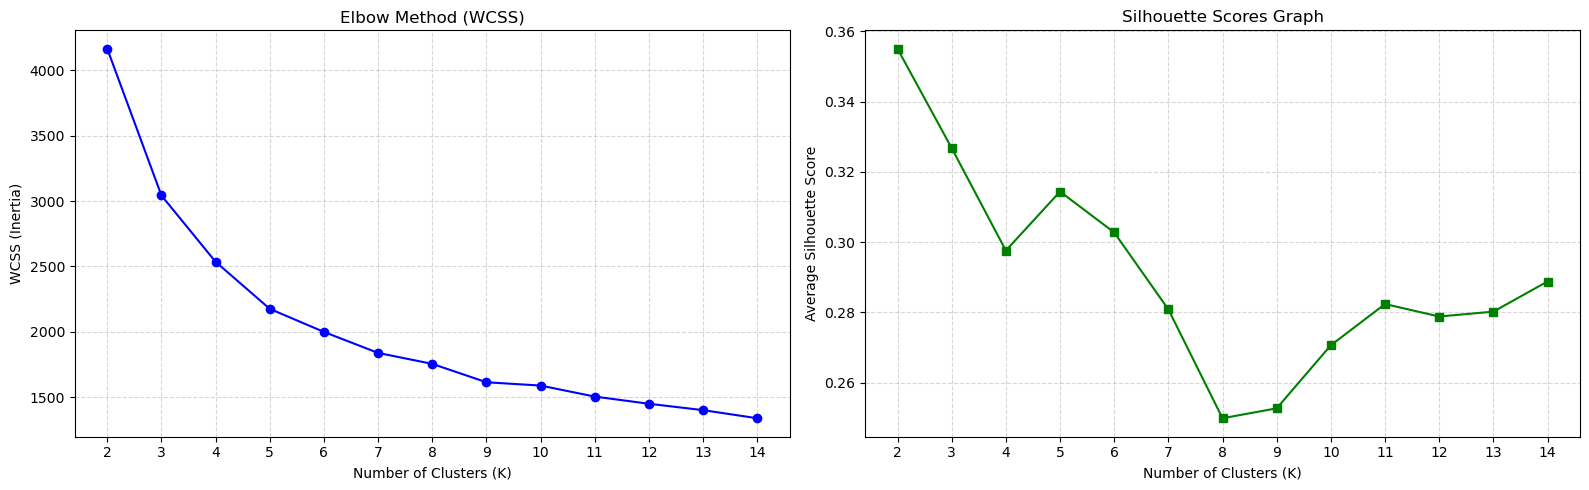

In [82]:
# SILHOUETTE SCORE AND WCSS
# 2. Run K-Means and evaluate Silhouette Scores
k_range_2 = range(2, 15)
silhouette_scores_2 = []

for k in k_range_2:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_2 = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels_2 = kmeans_eval_2.fit_predict(group2_features)

    # Calculate and print the average silhouette score
    score_2 = silhouette_score(group2_features, cluster_labels_2)
    silhouette_scores_2.append(score_2)
    print(f"For K = {k}, the average Silhouette Score is: {score_2:.2f}")

wcss_2 = []
wcss_range_2 = range (2, 15)

for w in wcss_range_2:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_2 = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow_2= kmeans_eval_2.fit(group2_features)
    wcss_2.append(elbow_2.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow_2.inertia_:2f}")
    
#PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range_2, wcss_2, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range_2)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range_2, silhouette_scores_2, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range_2)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

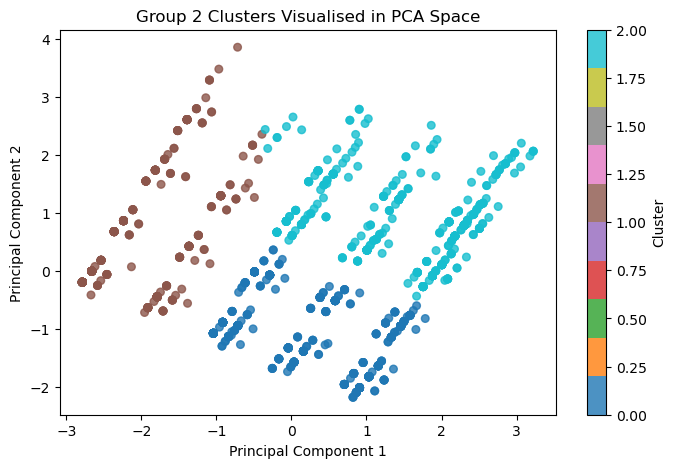

Total information retained from the 5 columns: 81.14%


In [83]:
group2_features= dataset[['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Consequences of discussing mental health',
                                                        'History of mental issues',
                                                        'Fear of others behavior, if mentally ill',
                                                        'Saw negative attitude towards mental health problems (Current or Previous Workplace)']]

kmeans2= KMeans(n_clusters= 3, random_state= 0)
dataset['Mental Health Stigma and its impact on Employee Performance']= kmeans2.fit_predict(group2_features)

pca2= PCA(n_components= 2)
pca_transformed2 =pca2.fit_transform(group2_features)

pca_df2= pd.DataFrame(pca_transformed2, columns= ['PC1', 'PC2'])

pca_df2['Group2_clusters']= dataset['Mental Health Stigma and its impact on Employee Performance']

plt.figure(figsize= (8, 5))
plt.scatter(
    pca_df2['PC1'],
    pca_df2['PC2'],
    c= dataset['Mental Health Stigma and its impact on Employee Performance'],
    cmap= 'tab10',
    alpha= 0.8,
    s= 30
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 2 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca2.explained_variance_ratio_) * 100
print(f"Total information retained from the 5 columns: {variance_captured:.2f}%")

In [85]:
#                         --------- GROUP 3 ---------
#       EVALUATING THE EFFECTIVENESS OF WORKPLACE SUPPORT 

group3_features= dataset[['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                            'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                            'Benefits Or Help Provided for Mental Health']]

For K = 2, the average Silhouette Score is: 0.55
For K = 3, the average Silhouette Score is: 0.46
For K = 4, the average Silhouette Score is: 0.35
For K = 5, the average Silhouette Score is: 0.35
For K = 6, the average Silhouette Score is: 0.36
For K = 7, the average Silhouette Score is: 0.48
For K = 8, the average Silhouette Score is: 0.47
For K = 9, the average Silhouette Score is: 0.49
For K = 10, the average Silhouette Score is: 0.49
For K = 11, the average Silhouette Score is: 0.53
For K = 12, the average Silhouette Score is: 0.55
For K = 13, the average Silhouette Score is: 0.59
For K = 14, the average Silhouette Score is: 0.61
For W = 2, the WCSS (inertia) is: 2620.726457
For W = 3, the WCSS (inertia) is: 1713.069407
For W = 4, the WCSS (inertia) is: 1198.507387
For W = 5, the WCSS (inertia) is: 994.012175
For W = 6, the WCSS (inertia) is: 842.131122
For W = 7, the WCSS (inertia) is: 767.096235
For W = 8, the WCSS (inertia) is: 707.110425
For W = 9, the WCSS (inertia) is: 645.24

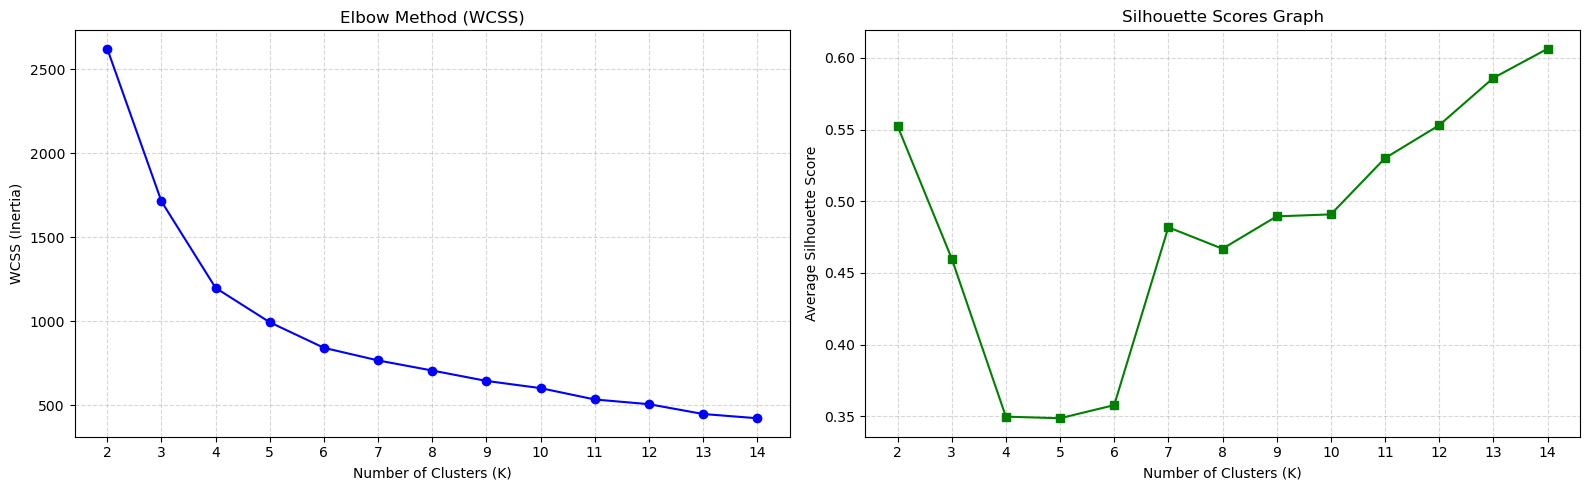

In [86]:
# SILHOUETTE SCORE AND WCSS
# 2. Run K-Means and evaluate Silhouette Scores
k_range_3 = range(2, 15)
silhouette_scores_3 = []

for k in k_range_3:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_3 = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels_3 = kmeans_eval_3.fit_predict(group3_features)

    # Calculate and print the average silhouette score
    score_3 = silhouette_score(group3_features, cluster_labels_3)
    silhouette_scores_3.append(score_3)
    print(f"For K = {k}, the average Silhouette Score is: {score_3:.2f}")

wcss_3 = []
wcss_range_3 = range (2, 15)

for w in wcss_range_3:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_3 = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow_3= kmeans_eval_3.fit(group3_features)
    wcss_3.append(elbow_3.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow_3.inertia_:2f}")
    
#PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Silhouette Scores
ax2.plot(k_range_3, silhouette_scores_3, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range_3)
ax2.grid(True, linestyle="--", alpha=0.5)

# Plot Elbow Method
ax1.plot(wcss_range_3, wcss_3, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range_3)
ax1.grid(True, linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()

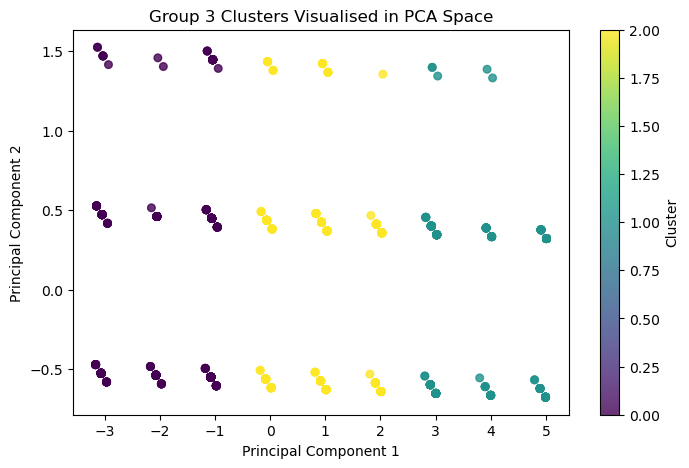

Total information retained from the 3 columns: 95.87%


In [ ]:
group3_features= dataset[['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                            'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                            'Benefits Or Help Provided for Mental Health']]

kmeans3= KMeans(n_clusters= 3, random_state= 0)
dataset['Evaluating the effectiveness of workplace support']= kmeans3.fit_predict(group3_features)

pca3= PCA(n_components= 2)
pca_transformed3 =pca3.fit_transform(group3_features)

pca_df3= pd.DataFrame(pca_transformed3, columns= ['PC1', 'PC2'])

pca_df3['Group3_clusters']= dataset['Evaluating the effectiveness of workplace support']

plt.figure(figsize= (8, 5))
plt.scatter(
    pca_df3['PC1'],
    pca_df3['PC2'],
    c= dataset['Evaluating the effectiveness of workplace support'],
    cmap= 'viridis',
    alpha= 0.8,
    s= 30
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 3 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca3.explained_variance_ratio_) * 100
print(f"Total information retained from the 3 columns: {variance_captured:.2f}%")

In [136]:
dataset.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace),Employee Mental Health across different Workplace Environments,Mental Health Stigma and its impact on Employee Performance,Evaluating the effectiveness of workplace support,Master_HR_Segment
0,4,1,1,1,1,1,1,1,0,1,0,0,0,39,1,1,1,0,2,3,0,2,2,2,0,0,0,0,2
1,5,1,1,2,2,0,0,1,2,1,1,1,1,29,1,1,0,6,4,3,0,4,1,2,0,1,0,1,0
2,5,1,1,1,1,1,2,1,0,0,1,0,0,38,1,1,2,0,2,2,1,1,2,2,2,0,1,0,2
3,4,1,1,1,1,1,1,1,2,1,1,1,1,43,1,1,1,2,2,3,1,2,2,2,1,0,0,0,1
4,5,0,1,0,1,1,0,1,2,1,1,1,1,43,2,1,1,4,3,1,2,4,1,2,3,0,2,2,1


In [137]:
group1= ['How many employees does your company or organization have?', 
                                            'Do you currently have a mental health disorder?',
                                            'Do you work remotely?', 
                                            'Benefits Or Help Provided for Mental Health']
group1_clusters_mean= dataset.groupby('Employee Mental Health across different Workplace Environments')[group1].mean()
group1_clusters_mean

,How many employees does your company or organization have?,Do you currently have a mental health disorder?,Do you work remotely?,Benefits Or Help Provided for Mental Health
Employee Mental Health across different Workplace Environments,,,,
0,4.245843,0.996437,1.055819,1.878860
1,2.634146,1.174216,0.986063,6.432056
2,1.761246,0.989619,0.910035,3.131488


In [93]:
group2= ['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                'Consequences of discussing mental health',
                'History of mental issues',
                'Fear of others behavior, if mentally ill',
                'Saw negative attitude towards mental health problems (Current or Previous Workplace)']
group2_clusters_mean= dataset.groupby('Mental Health Stigma and its impact on Employee Performance')[group2].mean()
group2_clusters_mean

,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?",Consequences of discussing mental health,History of mental issues,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace)
Mental Health Stigma and its impact on Employee Performance,,,,,
0,0.680000,0.798182,3.054545,1.965455,0.378182
1,0.146988,0.766265,0.318072,2.007229,0.821687
2,0.830022,1.172185,3.291391,2.174393,2.649007


In [94]:
group3= ['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                                        'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Benefits Or Help Provided for Mental Health']
group3_clusters_mean= dataset.groupby('Evaluating the effectiveness of workplace support')[group3].mean()
group3_clusters_mean

,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?",Benefits Or Help Provided for Mental Health
Evaluating the effectiveness of workplace support,,,
0,0.993289,0.553020,1.441611
1,1.493333,0.622222,6.826667
2,1.274554,0.578125,3.845982


In [96]:
dataset['Employee Mental Health across different Workplace Environments'].value_counts()

Employee Mental Health across different Workplace Environments
0    977
1    441
Name: count, dtype: int64

In [95]:
dataset['Mental Health Stigma and its impact on Employee Performance'].value_counts()

Mental Health Stigma and its impact on Employee Performance
0    550
2    453
1    415
Name: count, dtype: int64

In [97]:
dataset['Evaluating the effectiveness of workplace support'].value_counts()

Evaluating the effectiveness of workplace support
0    745
2    448
1    225
Name: count, dtype: int64

In [134]:
from sklearn.impute import SimpleImputer

# 1. Define the unique master list of features
unique_features = [
    'How many employees does your company or organization have?', 
    'Do you currently have a mental health disorder?',
    'Do you work remotely?', 
    'Benefits Or Help Provided for Mental Health',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
    'Consequences of discussing mental health',
    'History of mental issues',
    'Fear of others behavior, if mentally ill',
    'Saw negative attitude towards mental health problems (Current or Previous Workplace)',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'
]

# 2. Extract raw features from complete_dataset
joint_features = dataset[unique_features]

imputer= SimpleImputer(strategy= 'most_frequent')
imputed_data= imputer.fit_transform(joint_features)


# 5. Apply PCA to the Unified Space
pca_master = PCA(n_components=4, random_state=42)
pca_master_data = pca_master.fit_transform(imputed_data)

# 6. Run the Master K-Means
kmeans_master = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
dataset['Master_HR_Segment'] = kmeans_master.fit_predict(pca_master_data)

# 7. Print the Verification Score
score = silhouette_score(pca_master_data, dataset['Master_HR_Segment'])
print(f"Master Model Silhouette Score: {score:.3f}\n")

# =====================================================================
# 8. EVIDENCE GENERATION FOR HR (Percentage Distributions)
# =====================================================================
print("=====================================================================")
print("                      UNIFIED CLUSTER PROFILES                    ")
print("=====================================================================")

for feature in unique_features:
    print(f"\nDISTRIBUTION FOR: {feature}")
    print("-" * 60)
    
    # Generate the cross-tabulation table with percentages per cluster
    ct = pd.crosstab(
        index= dataset['Master_HR_Segment'], 
        columns= dataset[feature], 
        normalize='index'
    ) * 100
    
    # Format for neat reading
    print(ct.round(1).astype(str) + '%')

Master Model Silhouette Score: 0.274

                      UNIFIED CLUSTER PROFILES                    

DISTRIBUTION FOR: How many employees does your company or organization have?
------------------------------------------------------------
How many employees does your company or organization have?      1  ...     6
Master_HR_Segment                                                  ...      
0                                                           41.6%  ...  0.8%
1                                                            7.3%  ...  6.2%
2                                                            9.9%  ...  4.6%

[3 rows x 6 columns]

DISTRIBUTION FOR: Do you currently have a mental health disorder?
------------------------------------------------------------
Do you currently have a mental health disorder?      0      1      2
Master_HR_Segment                                                   
0                                                31.0%  21.1%  48.0%
1             

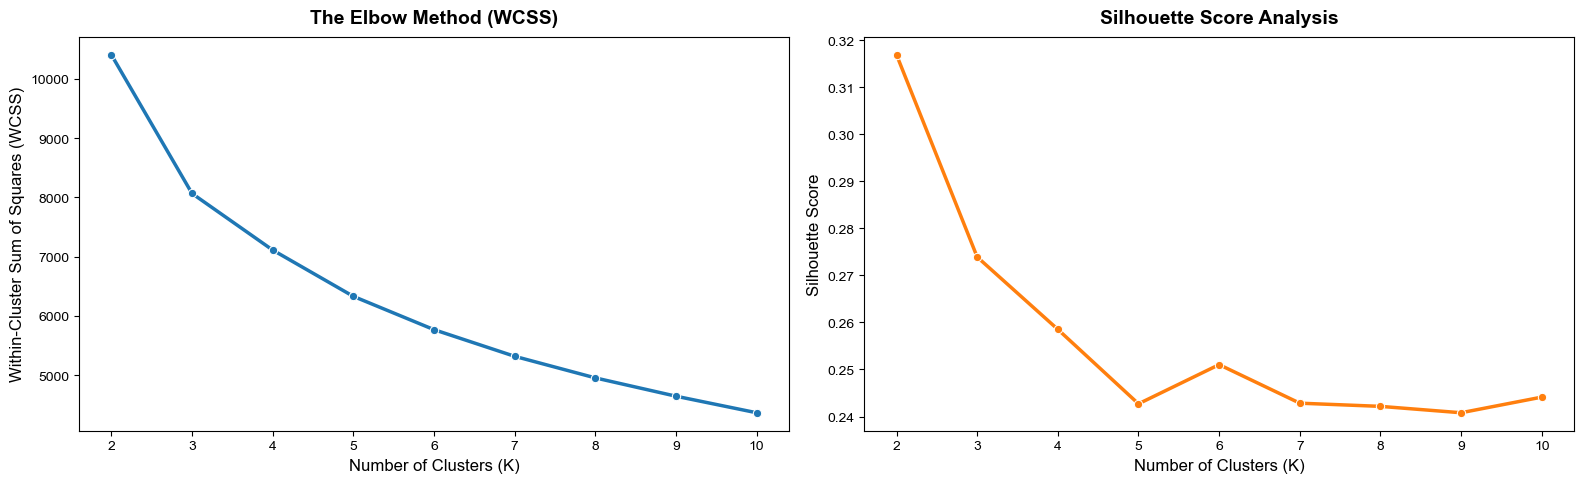

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize lists to store metrics
wcss = []
silhouette_scores = []
cluster_range = range(2, 11)

# 2. Loop through cluster counts to calculate WCSS and Silhouette scores
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_master_data) # Using your PCA transformed data
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_master_data, labels))

# 3. Create the side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Graph A: The Elbow Method (WCSS)
sns.lineplot(x=list(cluster_range), y=wcss, marker='o', color='#1f77b4', ax=ax[0], linewidth=2.5)
ax[0].set_title('The Elbow Method (WCSS)', fontsize=14, pad=10, weight='bold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax[0].set_xticks(list(cluster_range))

# Graph B: Silhouette Scores
sns.lineplot(x=list(cluster_range), y=silhouette_scores, marker='o', color='#ff7f0e', ax=ax[1], linewidth=2.5)
ax[1].set_title('Silhouette Score Analysis', fontsize=14, pad=10, weight='bold')
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[1].set_ylabel('Silhouette Score', fontsize=12)
ax[1].set_xticks(list(cluster_range))

# Highlight the peak or inflection point
plt.tight_layout()
plt.show()


**SCALING THE DATA FOR GETTING BETTER CLUSTERS**
---
USING STANDARD SCALAR FOR IT

In [100]:
from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()

# Scaling converts dataset into a numpy array
scaled_dataset = scale.fit_transform(dataset)

# Getting the column names back
scaled_dataset = pd.DataFrame(scaled_dataset, columns= dataset.columns)

In [101]:
scaled_dataset.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace),Employee Mental Health across different Workplace Environments,Mental Health Stigma and its impact on Employee Performance,Evaluating the effectiveness of workplace support,Master_HR_Segment
0,0.6,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.0,1.0,0.0,0.0,0.0,0.112500,0.0,0.0,0.5,0.00,0.250,0.75,0.000000,0.50,0.50,0.5,0.00,0.0,0.0,0.0,1.0
1,0.8,1.0,0.0,1.0,1.0,0.0,0.0,0.5,1.0,1.0,1.0,0.5,0.5,0.081250,0.0,0.0,0.0,0.75,0.500,0.75,0.000000,1.00,0.25,0.5,0.00,1.0,0.0,0.5,0.0
2,0.8,1.0,0.0,0.5,0.5,0.5,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.109375,0.0,0.0,1.0,0.00,0.250,0.50,0.333333,0.25,0.50,0.5,0.50,0.0,0.5,0.0,1.0
3,0.6,1.0,0.0,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,0.5,0.5,0.125000,0.0,0.0,0.5,0.25,0.250,0.75,0.333333,0.50,0.50,0.5,0.25,0.0,0.0,0.0,0.5
4,0.8,0.0,0.0,0.0,0.5,0.5,0.0,0.5,1.0,1.0,1.0,0.5,0.5,0.125000,0.5,0.0,0.5,0.50,0.375,0.25,0.666667,1.00,0.25,0.5,0.75,0.0,1.0,1.0,0.5


**MAKING GROUPS OF SPECIFIC FEATURES FOR CLUSTERS**

In [102]:
from sklearn.cluster import KMeans

kmeans = KMeans()

In [103]:
#                                               --------- GROUP 1 ---------
#       EMPLOYEE MENTAL HEALTH ACROSS DIFFERENT WORKPLACE ENVIRONMENTS

group1_features = scaled_dataset[['How many employees does your company or organization have?', 
                                                        'Do you currently have a mental health disorder?',
                                                        'Do you work remotely?', 
                                                        'Benefits Or Help Provided for Mental Health']]

**CALCULATING THE SILHOUETTE SCORES FOR OPTIMAL NUMBER OF CLUSTERS**

In [104]:
from sklearn.metrics import silhouette_score

PLOTTING THE SILHOUETTE SCORES AND THE ERRORS ASSOCIATED WITH IT

For K = 2, the average Silhouette Score is: 0.33
For K = 3, the average Silhouette Score is: 0.28
For K = 4, the average Silhouette Score is: 0.28
For K = 5, the average Silhouette Score is: 0.29
For K = 6, the average Silhouette Score is: 0.31
For K = 7, the average Silhouette Score is: 0.31
For K = 8, the average Silhouette Score is: 0.34
For K = 9, the average Silhouette Score is: 0.35
For K = 10, the average Silhouette Score is: 0.38
For K = 11, the average Silhouette Score is: 0.39
For K = 12, the average Silhouette Score is: 0.39
For K = 13, the average Silhouette Score is: 0.41
For K = 14, the average Silhouette Score is: 0.42
For W = 2, the WCSS (inertia) is: 426.332073
For W = 3, the WCSS (inertia) is: 355.250912
For W = 4, the WCSS (inertia) is: 302.570913
For W = 5, the WCSS (inertia) is: 261.579969
For W = 6, the WCSS (inertia) is: 227.499625
For W = 7, the WCSS (inertia) is: 205.566090
For W = 8, the WCSS (inertia) is: 186.124421
For W = 9, the WCSS (inertia) is: 171.30930

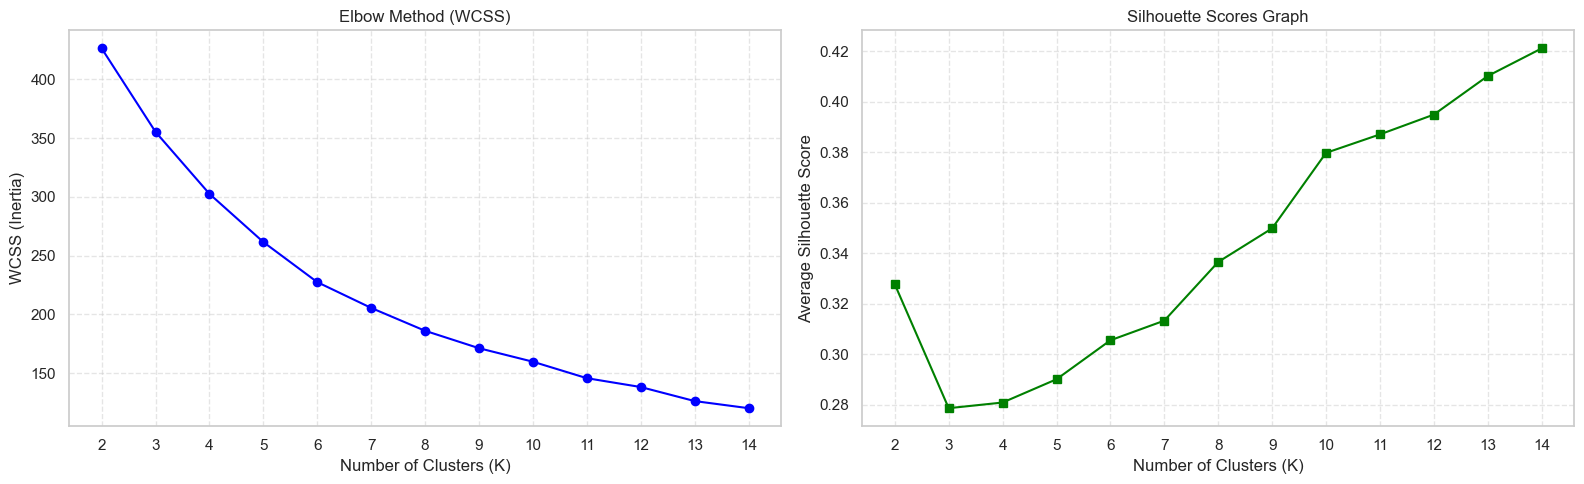

In [105]:
k_range = range(2, 15)
silhouette_scores =[]
for k in k_range:
    kmeans_eval = KMeans(n_clusters= k, random_state= 42, n_init= 10)
    cluster_labels = kmeans_eval.fit_predict(group1_features)

    # Calculate the average silhouette score for this K
    score = silhouette_score(group1_features, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")
    
#WCSS
 
wcss = []
wcss_range = range (2, 15)

for w in wcss_range:

    kmeans_eval = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow= kmeans_eval.fit(group1_features)
    wcss.append(elbow.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow.inertia_:2f}")
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range, wcss, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**VISUALISING THE GROUP AND THE NUMBER OF CLUSTERS**
---
USING PCA FOR REDUCING HIGH DIMENSIONAL VISUALISATION TO 2 DIMENSIONS

In [106]:
from sklearn.decomposition import PCA

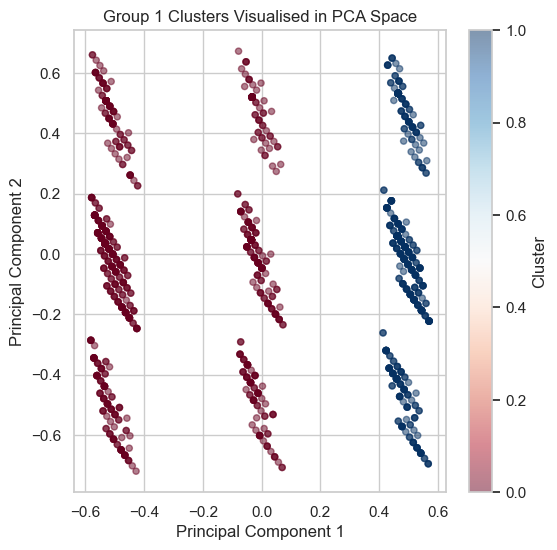

Total information retained from the 4 columns: 68.55%


In [107]:
group1_features = scaled_dataset[['How many employees does your company or organization have?', 
                                                        'Do you currently have a mental health disorder?',
                                                        'Do you work remotely?', 
                                                        'Benefits Or Help Provided for Mental Health']]

kmeans= KMeans(n_clusters= 2, random_state= 0)
scaled_dataset['Employee Mental Health across different Workplace Environments']= kmeans.fit_predict(group1_features)

# REDUCING THE DIMENSIONS
pca= PCA(n_components= 2)
pca_transformed= pca.fit_transform(group1_features)

# CREATING THE DATAFRAME FOR EASY VISUALISATION
pca_df= pd.DataFrame(pca_transformed, columns=['PC1', 'PC2'])

# ADDING CLUSTER LABELS
pca_df['Group1_clusters']= scaled_dataset['Employee Mental Health across different Workplace Environments']

# PLOTTING

plt.figure(figsize=(6, 6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c= scaled_dataset['Employee Mental Health across different Workplace Environments'],
    cmap= 'RdBu',
    alpha= 0.5,
    s= 20
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 1 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca.explained_variance_ratio_) * 100
print(f"Total information retained from the 4 columns: {variance_captured:.2f}%")

In [ ]:
scaled_dataset.head()

In [ ]:
scaled_dataset.columns

In [108]:
#                                         --------- GROUP 2 ---------
#       MENTAL HEALTH STIGMA AND ITS IMPACE ON EMPLOYEE PERFORMANCE

group2_features= scaled_dataset[['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Consequences of discussing mental health',
                                                        'History of mental issues',
                                                        'Fear of others behavior, if mentally ill',
                                                        'Saw negative attitude towards mental health problems (Current or Previous Workplace)']]

For K = 2, the average Silhouette Score is: 0.33
For K = 3, the average Silhouette Score is: 0.30
For K = 4, the average Silhouette Score is: 0.29
For K = 5, the average Silhouette Score is: 0.28
For K = 6, the average Silhouette Score is: 0.25
For K = 7, the average Silhouette Score is: 0.28
For K = 8, the average Silhouette Score is: 0.26
For K = 9, the average Silhouette Score is: 0.29
For K = 10, the average Silhouette Score is: 0.30
For K = 11, the average Silhouette Score is: 0.30
For K = 12, the average Silhouette Score is: 0.30
For K = 13, the average Silhouette Score is: 0.31
For K = 14, the average Silhouette Score is: 0.32
For W = 2, the WCSS (inertia) is: 357.492028
For W = 3, the WCSS (inertia) is: 282.806642
For W = 4, the WCSS (inertia) is: 249.676454
For W = 5, the WCSS (inertia) is: 225.629005
For W = 6, the WCSS (inertia) is: 199.059277
For W = 7, the WCSS (inertia) is: 178.621682
For W = 8, the WCSS (inertia) is: 164.969863
For W = 9, the WCSS (inertia) is: 159.62688

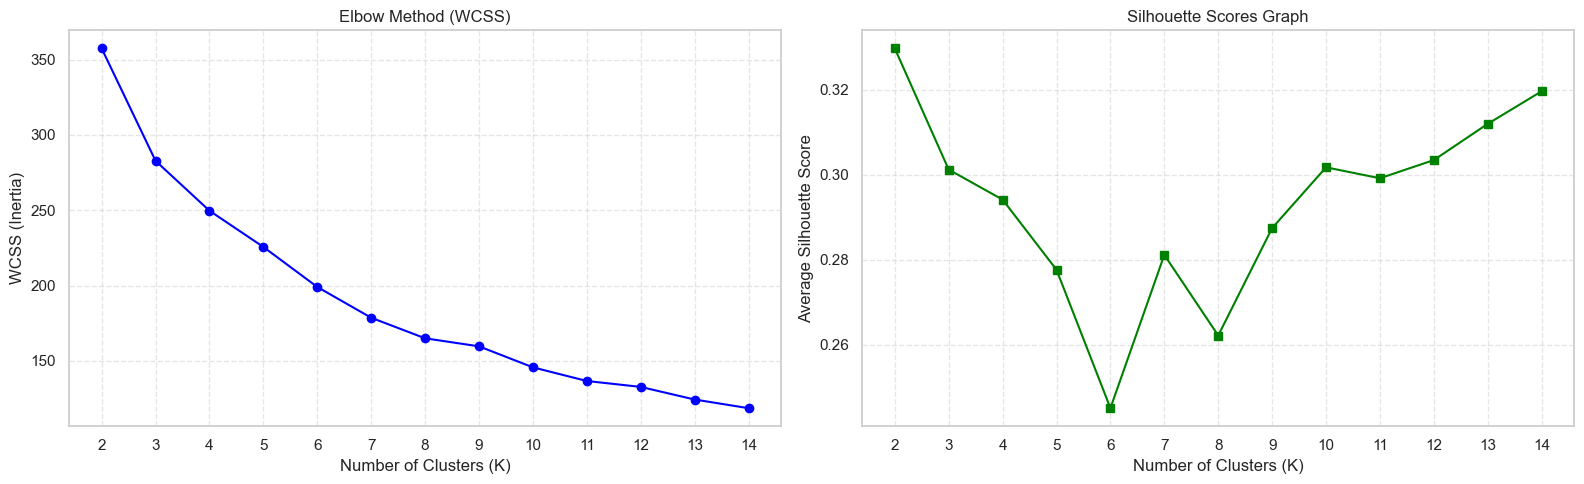

In [109]:
# SILHOUETTE SCORE AND WCSS
# 2. Run K-Means and evaluate Silhouette Scores
k_range_2 = range(2, 15)
silhouette_scores_2 = []

for k in k_range_2:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_2 = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels_2 = kmeans_eval_2.fit_predict(group2_features)

    # Calculate and print the average silhouette score
    score_2 = silhouette_score(group2_features, cluster_labels_2)
    silhouette_scores_2.append(score_2)
    print(f"For K = {k}, the average Silhouette Score is: {score_2:.2f}")

wcss_2 = []
wcss_range_2 = range (2, 15)

for w in wcss_range_2:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_2 = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow_2= kmeans_eval_2.fit(group2_features)
    wcss_2.append(elbow_2.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow_2.inertia_:2f}")
    
#PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range_2, wcss_2, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range_2)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range_2, silhouette_scores_2, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range_2)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

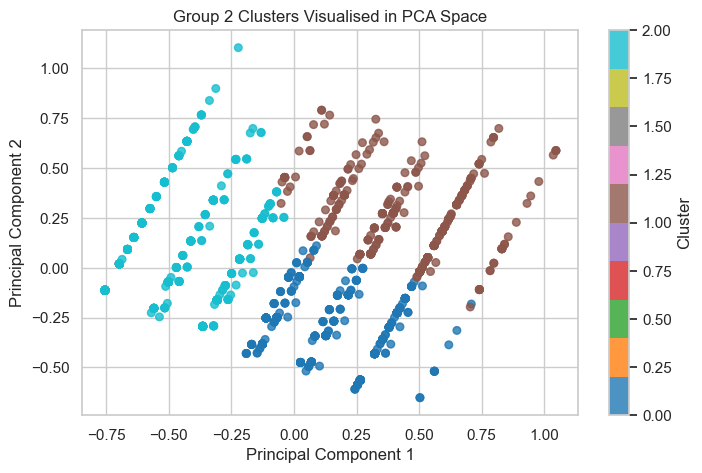

Total information retained from the 5 columns: 71.41%


In [110]:
group2_features= scaled_dataset[['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Consequences of discussing mental health',
                                                        'History of mental issues',
                                                        'Fear of others behavior, if mentally ill',
                                                        'Saw negative attitude towards mental health problems (Current or Previous Workplace)']]

kmeans2= KMeans(n_clusters= 3, random_state= 0)
scaled_dataset['Mental Health Stigma and its impact on Employee Performance']= kmeans2.fit_predict(group2_features)

pca2= PCA(n_components= 2)
pca_transformed2 =pca2.fit_transform(group2_features)

pca_df2= pd.DataFrame(pca_transformed2, columns= ['PC1', 'PC2'])

pca_df2['Group2_clusters']= scaled_dataset['Mental Health Stigma and its impact on Employee Performance']

plt.figure(figsize= (8, 5))
plt.scatter(
    pca_df2['PC1'],
    pca_df2['PC2'],
    c= scaled_dataset['Mental Health Stigma and its impact on Employee Performance'],
    cmap= 'tab10',
    alpha= 0.8,
    s= 30
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 2 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca2.explained_variance_ratio_) * 100
print(f"Total information retained from the 5 columns: {variance_captured:.2f}%")

In [ ]:
scaled_dataset.head()

In [111]:
#                         --------- GROUP 3 ---------
#       EVALUATING THE EFFECTIVENESS OF WORKPLACE SUPPORT 

group3_features= scaled_dataset[['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                                        'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Benefits Or Help Provided for Mental Health']]

For K = 2, the average Silhouette Score is: 0.40
For K = 3, the average Silhouette Score is: 0.47
For K = 4, the average Silhouette Score is: 0.47
For K = 5, the average Silhouette Score is: 0.47
For K = 6, the average Silhouette Score is: 0.53
For K = 7, the average Silhouette Score is: 0.54
For K = 8, the average Silhouette Score is: 0.56
For K = 9, the average Silhouette Score is: 0.58
For K = 10, the average Silhouette Score is: 0.60
For K = 11, the average Silhouette Score is: 0.60
For K = 12, the average Silhouette Score is: 0.61
For K = 13, the average Silhouette Score is: 0.61
For K = 14, the average Silhouette Score is: 0.63
For W = 2, the WCSS (inertia) is: 202.413509
For W = 3, the WCSS (inertia) is: 132.319286
For W = 4, the WCSS (inertia) is: 107.585491
For W = 5, the WCSS (inertia) is: 88.499439
For W = 6, the WCSS (inertia) is: 74.039646
For W = 7, the WCSS (inertia) is: 64.842973
For W = 8, the WCSS (inertia) is: 54.254028
For W = 9, the WCSS (inertia) is: 47.010047
For

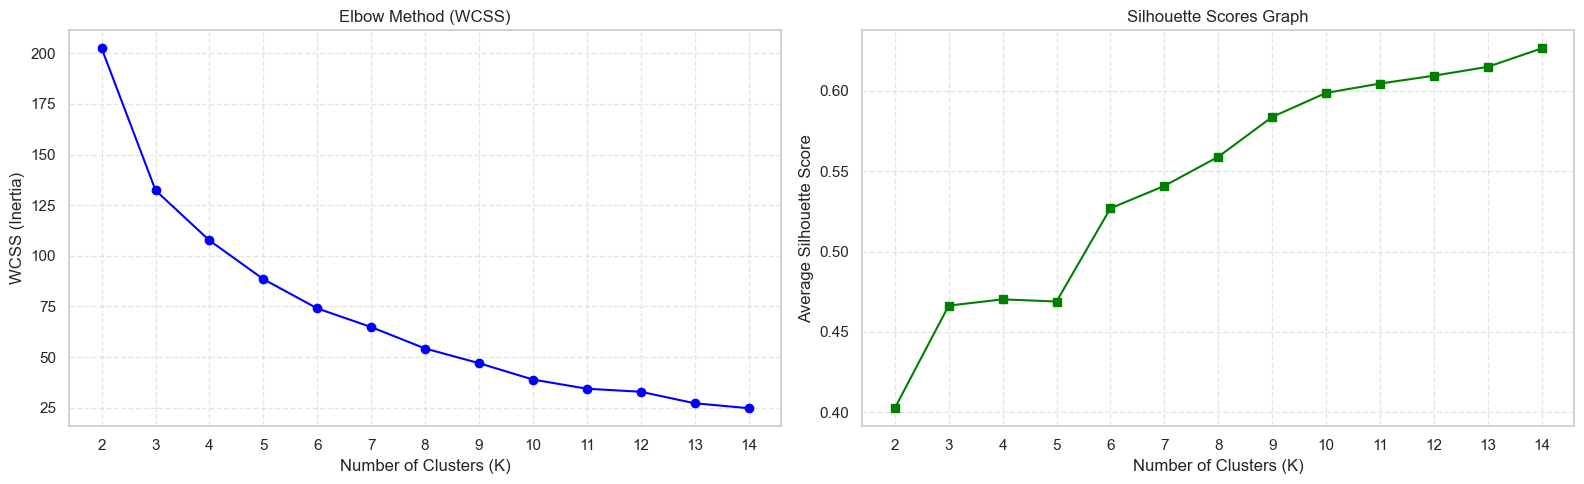

In [112]:
# SILHOUETTE SCORE AND WCSS
# 2. Run K-Means and evaluate Silhouette Scores
k_range_3 = range(2, 15)
silhouette_scores_3 = []

for k in k_range_3:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_3 = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels_3 = kmeans_eval_3.fit_predict(group3_features)

    # Calculate and print the average silhouette score
    score_3 = silhouette_score(group3_features, cluster_labels_3)
    silhouette_scores_3.append(score_3)
    print(f"For K = {k}, the average Silhouette Score is: {score_3:.2f}")

wcss_3 = []
wcss_range_3 = range (2, 15)

for w in wcss_range_3:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval_3 = KMeans(n_clusters=w, random_state=42, n_init= 10)
    elbow_3= kmeans_eval_3.fit(group3_features)
    wcss_3.append(elbow_3.inertia_)
    print(f"For W = {w}, the WCSS (inertia) is: {elbow_3.inertia_:2f}")
    
#PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Silhouette Scores
ax2.plot(k_range_3, silhouette_scores_3, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range_3)
ax2.grid(True, linestyle="--", alpha=0.5)

# Plot Elbow Method
ax1.plot(wcss_range_3, wcss_3, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range_3)
ax1.grid(True, linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()

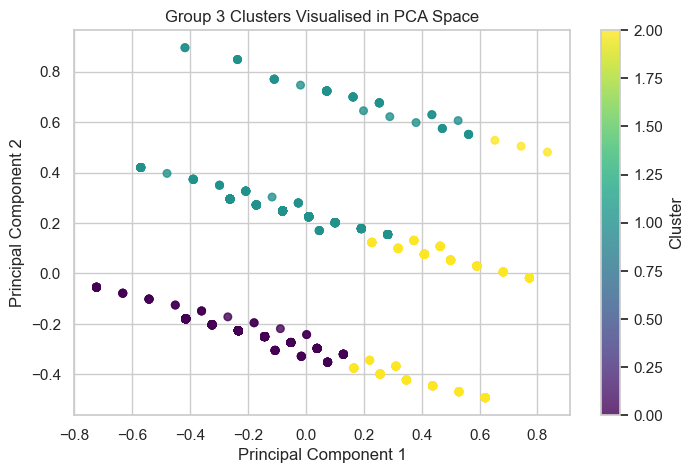

Total information retained from the 3 columns: 81.79%


In [114]:
group3_features= scaled_dataset[['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                                        'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Benefits Or Help Provided for Mental Health']]

kmeans3= KMeans(n_clusters= 3, random_state= 0)
scaled_dataset['Evaluating the effectiveness of workplace support']= kmeans3.fit_predict(group3_features)

pca3= PCA(n_components= 2)
pca_transformed3 =pca3.fit_transform(group3_features)

pca_df3= pd.DataFrame(pca_transformed3, columns= ['PC1', 'PC2'])

pca_df3['Group3_clusters']= scaled_dataset['Evaluating the effectiveness of workplace support']

plt.figure(figsize= (8, 5))
plt.scatter(
    pca_df3['PC1'],
    pca_df3['PC2'],
    c= scaled_dataset['Evaluating the effectiveness of workplace support'],
    cmap= 'viridis',
    alpha= 0.8,
    s= 30
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Group 3 Clusters Visualised in PCA Space')
plt.colorbar(label= 'Cluster')
plt.show()

# 6. Check information retention
variance_captured = sum(pca3.explained_variance_ratio_) * 100
print(f"Total information retained from the 3 columns: {variance_captured:.2f}%")

In [115]:
scaled_dataset.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace),Employee Mental Health across different Workplace Environments,Mental Health Stigma and its impact on Employee Performance,Evaluating the effectiveness of workplace support,Master_HR_Segment
0,0.6,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.0,1.0,0.0,0.0,0.0,0.112500,0.0,0.0,0.5,0.00,0.250,0.75,0.000000,0.50,0.50,0.5,0.00,0,2,0,1.0
1,0.8,1.0,0.0,1.0,1.0,0.0,0.0,0.5,1.0,1.0,1.0,0.5,0.5,0.081250,0.0,0.0,0.0,0.75,0.500,0.75,0.000000,1.00,0.25,0.5,0.00,1,0,2,0.0
2,0.8,1.0,0.0,0.5,0.5,0.5,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.109375,0.0,0.0,1.0,0.00,0.250,0.50,0.333333,0.25,0.50,0.5,0.50,0,2,0,1.0
3,0.6,1.0,0.0,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,0.5,0.5,0.125000,0.0,0.0,0.5,0.25,0.250,0.75,0.333333,0.50,0.50,0.5,0.25,1,0,1,0.5
4,0.8,0.0,0.0,0.0,0.5,0.5,0.0,0.5,1.0,1.0,1.0,0.5,0.5,0.125000,0.5,0.0,0.5,0.50,0.375,0.25,0.666667,1.00,0.25,0.5,0.75,1,1,1,0.5


In [116]:
scaled_dataset.to_csv('Cleaned and Min Max Scaled Mental Health Data with Clusters.csv', index= False)

**ATTACHING THE ASSIGNED CLUSTERS TO THE UNSCALED DATA FOR EASY INTERPRETATION**

In [117]:
columns_to_attach = ['Employee Mental Health across different Workplace Environments', 'Mental Health Stigma and its impact on Employee Performance', 'Evaluating the effectiveness of workplace support']

complete_dataset= pd.concat([dataset, scaled_dataset[columns_to_attach]], axis= 1)

In [118]:
complete_dataset.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,Which of the following best describes your work position?,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace),Employee Mental Health across different Workplace Environments,Mental Health Stigma and its impact on Employee Performance,Evaluating the effectiveness of workplace support,Master_HR_Segment,Employee Mental Health across different Workplace Environments,Mental Health Stigma and its impact on Employee Performance,Evaluating the effectiveness of workplace support
0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,39.0,1.0,1.0,1.0,0.0,2.0,3.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
1,5.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,1.0,29.0,1.0,1.0,0.0,6.0,4.0,3.0,0.0,4.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0
2,5.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,38.0,1.0,1.0,2.0,0.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0
3,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,43.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,5.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,1.0,43.0,2.0,1.0,1.0,4.0,3.0,1.0,2.0,4.0,1.0,2.0,3.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0


**CALCULATING THE MEAN SCORE OF THE CLUSTERS FOR INTERPRETATION**
---
SPECIFING GROUP 1, 2, AND 3 COLUMNS SO THAT ONLY THE VALUES IN THESE COLUMNS COME INTO CONSIDERATION 

In [ ]:
group1= ['How many employees does your company or organization have?', 
                                            'Do you currently have a mental health disorder?',
                                            'Do you work remotely?', 
                                            'Benefits Or Help Provided for Mental Health']
group1_clusters_mean= complete_dataset.groupby('Employee Mental Health across different Workplace Environments')[group1].mean()
group1_clusters_mean

In [124]:
group1 = [
    'How many employees does your company or organization have?', 
    'Do you currently have a mental health disorder?',
    'Do you work remotely?', 
    'Benefits Or Help Provided for Mental Health'
]

# 1. Grab only the very first column that has this name
grouper_column = complete_dataset['Employee Mental Health across different Workplace Environments']

if isinstance(grouper_column, pd.DataFrame):
    # If it is a DataFrame, it means duplicates exist. Take the first one.
    grouper_column = grouper_column.iloc[:, 0]

# 2. Pass this clean, 1D column directly into groupby
group1_clusters_mean = complete_dataset.groupby(grouper_column)[group1].mean()

group1_clusters_mean

,How many employees does your company or organization have?,Do you currently have a mental health disorder?,Do you work remotely?,Benefits Or Help Provided for Mental Health
Employee Mental Health across different Workplace Environments,,,,
0.0,3.925281,0.987718,1.038895,1.905834
1.0,2.278912,1.126984,0.952381,5.603175


In [ ]:
# View the Median (the middle ranking, which respects the ordinal scale)
group1_clusters_median = complete_dataset.groupby('Employee Mental Health across different Workplace Environments')[group1].median()
print("--- Cluster Medians ---")
print(group1_clusters_median)

# View the Mode (the most common response in each cluster)
print("\n--- Cluster Modes ---")
group1_clusters_mode = complete_dataset.groupby('Employee Mental Health across different Workplace Environments')[group1].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
print(group1_clusters_mode)

In [ ]:
cluster_col = 'Employee Mental Health across different Workplace Environments'

for feature in group1:
    print(f"\n=========================================")
    print(f"DISTRIBUTION FOR: {feature}")
    print(f"=========================================")
    
    # Creates a cross-tabulation showing the percentage of each score within each cluster
    ct = pd.crosstab(complete_dataset[cluster_col], complete_dataset[feature], normalize='index') * 100
    print(ct.round(1).astype(str) + '%')

In [ ]:
group2= ['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                'Consequences of discussing mental health',
                'History of mental issues',
                'Fear of others behavior, if mentally ill',
                'Saw negative attitude towards mental health problems (Current or Previous Workplace)']
group2_clusters_mean= complete_dataset.groupby('Mental Health Stigma and its impact on Employee Performance')[group2].mean()
group2_clusters_mean

In [129]:
group2= ['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                'Consequences of discussing mental health',
                'History of mental issues',
                'Fear of others behavior, if mentally ill',
                'Saw negative attitude towards mental health problems (Current or Previous Workplace)']
# 1. Grab only the very first column that has this name
grouper_column = complete_dataset['Mental Health Stigma and its impact on Employee Performance']

if isinstance(grouper_column, pd.DataFrame):
    # If it is a DataFrame, it means duplicates exist. Take the first one.
    grouper_column = grouper_column.iloc[:, 0]

# 2. Pass this clean, 1D column directly into groupby
group2_clusters_mean = complete_dataset.groupby(grouper_column)[group2].mean()

group2_clusters_mean

,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?",Consequences of discussing mental health,History of mental issues,"Fear of others behavior, if mentally ill",Saw negative attitude towards mental health problems (Current or Previous Workplace)
Mental Health Stigma and its impact on Employee Performance,,,,,
0.0,0.680000,0.798182,3.054545,1.965455,0.378182
1.0,0.146988,0.766265,0.318072,2.007229,0.821687
2.0,0.830022,1.172185,3.291391,2.174393,2.649007


In [ ]:
group3= ['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                                        'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Benefits Or Help Provided for Mental Health']
group3_clusters_mean= complete_dataset.groupby('Evaluating the effectiveness of workplace support')[group3].mean()
group3_clusters_mean

In [130]:
group3= ['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
                                                        'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
                                                        'Benefits Or Help Provided for Mental Health']
# 1. Grab only the very first column that has this name
grouper_column = complete_dataset['Evaluating the effectiveness of workplace support']

if isinstance(grouper_column, pd.DataFrame):
    # If it is a DataFrame, it means duplicates exist. Take the first one.
    grouper_column = grouper_column.iloc[:, 0]

# 2. Pass this clean, 1D column directly into groupby
group3_clusters_mean = complete_dataset.groupby(grouper_column)[group3].mean()

group3_clusters_mean

,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?",Benefits Or Help Provided for Mental Health
Evaluating the effectiveness of workplace support,,,
0.0,0.993289,0.553020,1.441611
1.0,1.493333,0.622222,6.826667
2.0,1.274554,0.578125,3.845982


In [ ]:
complete_dataset['Mental Health Stigma and its impact on Employee Performance'].value_counts()

In [ ]:
complete_dataset.to_csv('Cleaned Mental Health Data.csv', index= False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Define the unique master list of features
unique_features = [
    'How many employees does your company or organization have?', 
    'Do you currently have a mental health disorder?',
    'Do you work remotely?', 
    'Benefits Or Help Provided for Mental Health',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
    'Consequences of discussing mental health',
    'History of mental issues',
    'Fear of others behavior, if mentally ill',
    'Saw negative attitude towards mental health problems (Current or Previous Workplace)',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'
]

# 2. Extract raw features from complete_dataset
joint_features = complete_dataset[unique_features]

imputer= SimpleImputer(strategy= 'most_frequent')
imputed_data= imputer.fit_transform(joint_features)

# 3. Scale the imputed data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# 5. Apply PCA to the Unified Space
pca_master = PCA(n_components=4, random_state=42)
pca_master_data = pca_master.fit_transform(scaled_data)

# 6. Run the Master K-Means
kmeans_master = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
complete_dataset['Master_HR_Segment'] = kmeans_master.fit_predict(pca_master_data)

# 7. Print the Verification Score
score = silhouette_score(pca_master_data, complete_dataset['Master_HR_Segment'])
print(f"Master Model Silhouette Score: {score:.3f}\n")

# =====================================================================
# 8. EVIDENCE GENERATION FOR HR (Percentage Distributions)
# =====================================================================
print("=====================================================================")
print("                      UNIFIED CLUSTER PROFILES                    ")
print("=====================================================================")

for feature in unique_features:
    print(f"\nDISTRIBUTION FOR: {feature}")
    print("-" * 60)
    
    # Generate the cross-tabulation table with percentages per cluster
    ct = pd.crosstab(
        index= complete_dataset['Master_HR_Segment'], 
        columns= complete_dataset[feature], 
        normalize='index'
    ) * 100
    
    # Format for neat reading
    print(ct.round(1).astype(str) + '%')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize lists to store metrics
wcss = []
silhouette_scores = []
cluster_range = range(2, 11)

# 2. Loop through cluster counts to calculate WCSS and Silhouette scores
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_master_data) # Using your PCA transformed data
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_master_data, labels))

# 3. Create the side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Graph A: The Elbow Method (WCSS)
sns.lineplot(x=list(cluster_range), y=wcss, marker='o', color='#1f77b4', ax=ax[0], linewidth=2.5)
ax[0].set_title('The Elbow Method (WCSS)', fontsize=14, pad=10, weight='bold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax[0].set_xticks(list(cluster_range))

# Graph B: Silhouette Scores
sns.lineplot(x=list(cluster_range), y=silhouette_scores, marker='o', color='#ff7f0e', ax=ax[1], linewidth=2.5)
ax[1].set_title('Silhouette Score Analysis', fontsize=14, pad=10, weight='bold')
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[1].set_ylabel('Silhouette Score', fontsize=12)
ax[1].set_xticks(list(cluster_range))

# Highlight the peak or inflection point
plt.tight_layout()
plt.show()
